<a href="https://colab.research.google.com/github/vanshey0009/Naive_bayes/blob/main/project_UsingNaiveBayes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# PROJECT : TEXT ANALYTICS FOR SPAM DETECTION USING NAIVE BAYES

In [4]:
import pandas as pd # pandas is use for load data , create features , clean data , etc.
import numpy as np # numerical python is use for faster numerical computation
df=pd.read_csv('/content/train.csv')
print(df.head())

                                                 sms  label
0  Go until jurong point, crazy.. Available only ...      0
1                    Ok lar... Joking wif u oni...\n      0
2  Free entry in 2 a wkly comp to win FA Cup fina...      1
3  U dun say so early hor... U c already then say...      0
4  Nah I don't think he goes to usf, he lives aro...      0


In [ ]:
message = 'sms'
target = 'label'
X = df[message]
y = df[target]

print(df.shape)
print(df.info)

(5574, 2)
<bound method DataFrame.info of                                                     sms  label
0     Go until jurong point, crazy.. Available only ...      0
1                       Ok lar... Joking wif u oni...\n      0
2     Free entry in 2 a wkly comp to win FA Cup fina...      1
3     U dun say so early hor... U c already then say...      0
4     Nah I don't think he goes to usf, he lives aro...      0
...                                                 ...    ...
5569  This is the 2nd time we have tried 2 contact u...      1
5570             Will ü b going to esplanade fr home?\n      0
5571  Pity, * was in mood for that. So...any other s...      0
5572  The guy did some bitching but I acted like i'd...      0
5573                       Rofl. Its true to its name\n      0

[5574 rows x 2 columns]>


In [ ]:
from sklearn.model_selection import train_test_split  # it is used spilt a data in training and testing dataset
X_train, X_test, y_train, y_test = train_test_split(

    X, y, test_size=0.2,
    random_state=42
    )

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer # it convert text data into numerical data

vectorizer = CountVectorizer(stop_words='english')
X_train_counts = vectorizer.fit_transform(X_train)

X_test_counts = vectorizer.transform(X_test)


In [ ]:
from sklearn.naive_bayes import MultinomialNB
# Multinomial Naive Bayes is a classification algorithm commonly used for text classification tasks

clf = MultinomialNB()
clf.fit(X_train_counts, y_train)


y_pred = clf.predict(X_test_counts)
clf = MultinomialNB()
clf.fit(X_train_counts, y_train)


from sklearn.metrics import accuracy_score, classification_report
# Accuracy= Total Predictions / Number of Correct Predictions.

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.9847533632286996

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99       954
           1       0.96      0.93      0.95       161

    accuracy                           0.98      1115
   macro avg       0.98      0.96      0.97      1115
weighted avg       0.98      0.98      0.98      1115



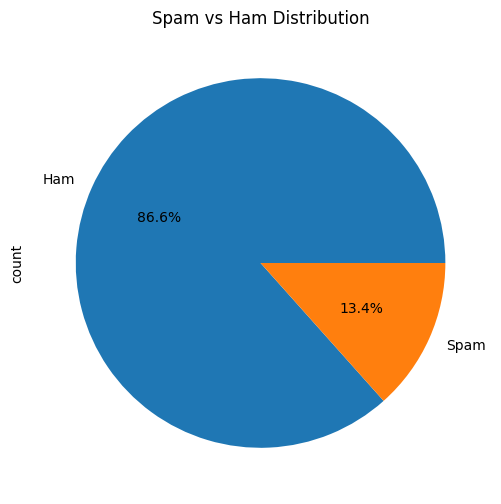

In [ ]:
import matplotlib.pyplot as plt
# used for data visualization and plotting graphs, charts.
plt.figure(figsize=(6,6))

df['label'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    labels=['Ham','Spam']
)

plt.title("Spam vs Ham Distribution")
plt.show()

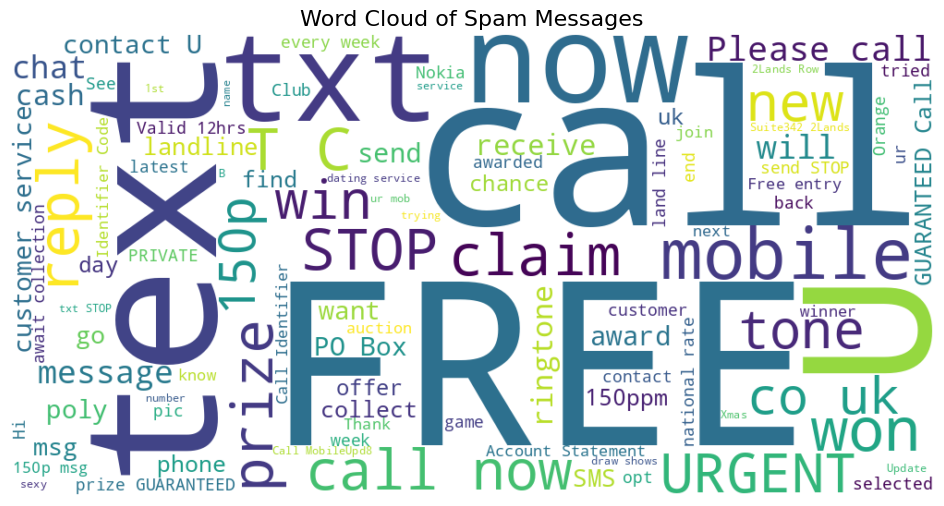

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Combine all spam messages into one text
spam_text = " ".join(df[df['label'] == 1]['sms'])

# Generate Word Cloud
wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white',
    max_words=100
).generate(spam_text)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud of Spam Messages", fontsize=16)
plt.show()

In [ ]:
import pandas as pd

# Create error analysis dataframe
error_df = pd.DataFrame({
    'Message': X_test,
    'Actual Label': y_test,
    'Predicted Label': y_pred
})

# Keep only incorrect predictions
errors = error_df[error_df['Actual Label'] != error_df['Predicted Label']]

# Replace labels with names
errors['Actual Label'] = errors['Actual Label'].map({0:'Ham', 1:'Spam'})
errors['Predicted Label'] = errors['Predicted Label'].map({0:'Ham', 1:'Spam'})

print("Number of Misclassified Messages:", len(errors))
errors.head(20)

Number of Misclassified Messages: 17


/tmp/ipykernel_3430/3383465537.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  errors['Actual Label'] = errors['Actual Label'].map({0:'Ham', 1:'Spam'})
/tmp/ipykernel_3430/3383465537.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  errors['Predicted Label'] = errors['Predicted Label'].map({0:'Ham', 1:'Spam'})


,Message,Actual Label,Predicted Label
3742,2/2 146tf150p\n,Spam,Ham
4600,Have you laid your airtel line to rest?\n,Ham,Spam
1893,CALL 09090900040 & LISTEN TO EXTREME DIRTY LIV...,Spam,Ham
4419,"When you get free, call me\n",Ham,Spam
2663,Hello darling how are you today? I would love ...,Spam,Ham
4821,Check Out Choose Your Babe Videos @ sms.shsex....,Spam,Ham
751,"Do you realize that in about 40 years, we'll h...",Spam,Ham
4702,I liked the new mobile\n,Ham,Spam
3864,Oh my god! I've found your number again! I'm s...,Spam,Ham
5046,We have sent JD for Customer Service cum Accou...,Ham,Spam


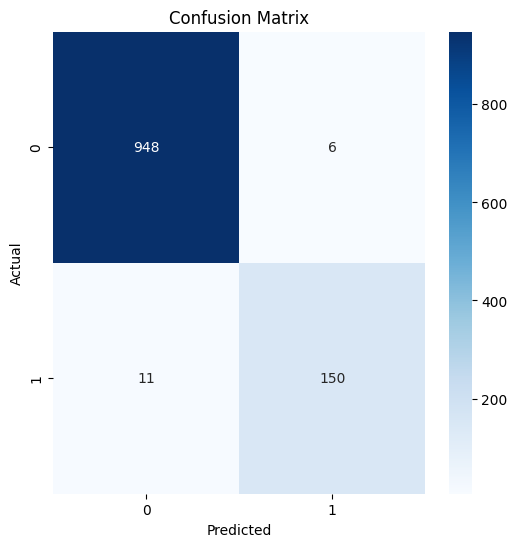

In [ ]:
from sklearn.metrics import confusion_matrix
# it is use for comparing the actual values with the predicted values.
import matplotlib.pyplot as plt
import seaborn as sns # It is used to create attractive and informative statistical graphs with less code.

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

/tmp/ipykernel_3430/1589550033.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='spam indicator', y='word', data=top_spam_words, palette='deep')


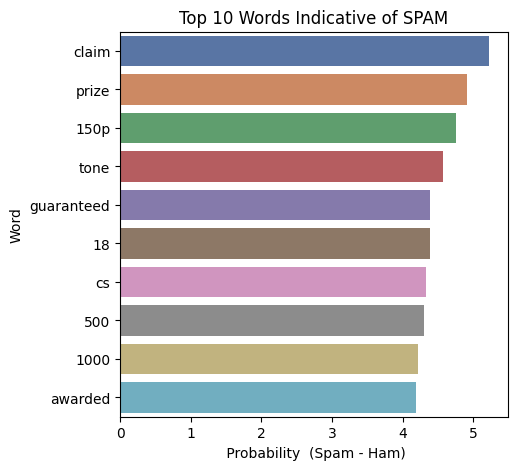

/tmp/ipykernel_3430/1589550033.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='spam indicator', y='word', data=top_ham_words, palette='deep')


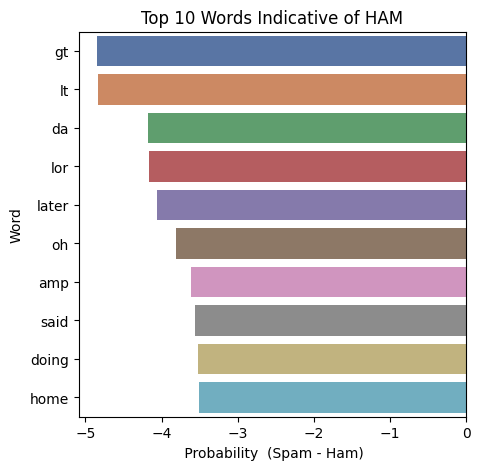

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

feature_names = vectorizer.get_feature_names_out()
log_probs_ham = clf.feature_log_prob_[0]
log_probs_spam = clf.feature_log_prob_[1]


words = pd.DataFrame({
    'word': feature_names,
    'ham sms': log_probs_ham,
    'spam sms': log_probs_spam
})


words['spam indicator'] = words['spam sms'] - words['ham sms']


top_spam_words = words.sort_values(by='spam indicator', ascending=False).head(10)

top_ham_words = words.sort_values(by='spam indicator', ascending=True).head(10)


plt.figure(figsize=(5, 5))
sns.barplot(x='spam indicator', y='word', data=top_spam_words, palette='deep')
plt.title('Top 10 Words Indicative of SPAM')
plt.xlabel(' Probability  (Spam - Ham)')
plt.ylabel('Word')
plt.show()


plt.figure(figsize=(5, 5))
sns.barplot(x='spam indicator', y='word', data=top_ham_words, palette='deep')
plt.title('Top 10 Words Indicative of HAM')
plt.xlabel(' Probability  (Spam - Ham)')
plt.ylabel('Word')
plt.show()

### Message Length Analysis

Let's analyze the length of the messages to see if there's a difference between spam and ham messages.

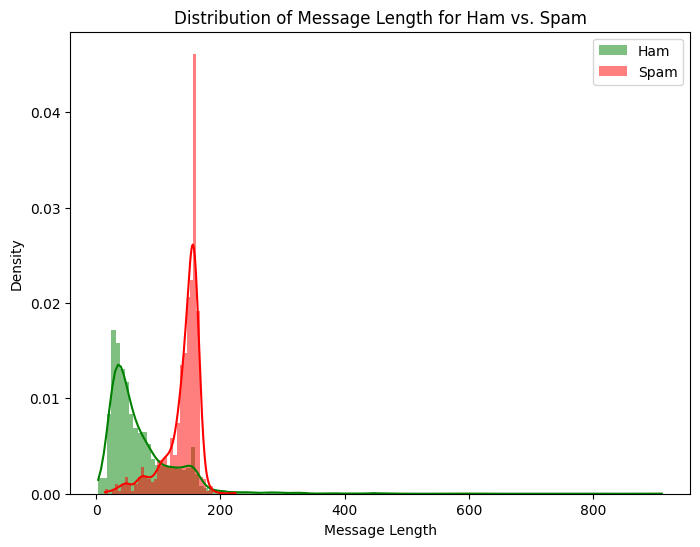

In [ ]:
df['message_length'] = df['sms'].apply(len)

plt.figure(figsize=(8, 6))
sns.histplot(df[df['label']==0]['message_length'], color='green', label='Ham', kde=True, stat='density', linewidth=0)
sns.histplot(df[df['label']==1]['message_length'], color='red', label='Spam', kde=True, stat='density', linewidth=0)
plt.title('Distribution of Message Length for Ham vs. Spam')
plt.xlabel('Message Length')
plt.ylabel('Density')
plt.legend()
plt.show()

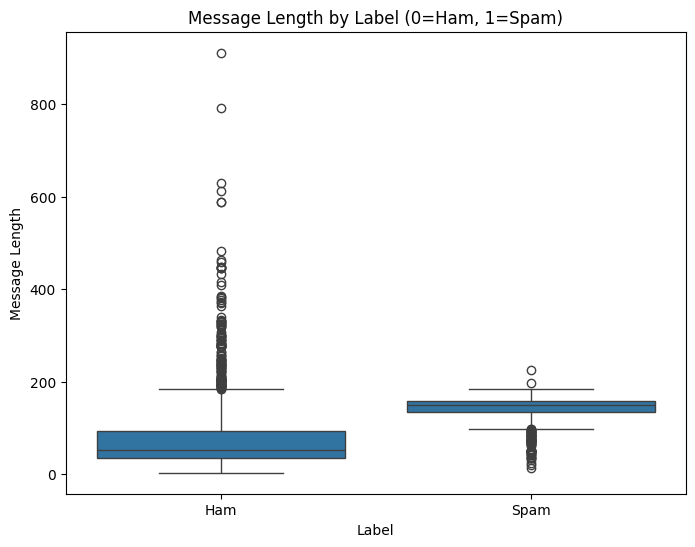

In [ ]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='label', y='message_length', data=df)
plt.title('Message Length by Label (0=Ham, 1=Spam)')
plt.xlabel('Label')
plt.ylabel('Message Length')
plt.xticks(ticks=[0, 1], labels=['Ham', 'Spam'])
plt.show()

In [ ]:
from IPython.display import HTML, display
import time

# Enter Message Screen
display(HTML("""
<div style="
width:80%;
margin:auto;
padding:30px;
text-align:center;
background:linear-gradient(135deg,#4facfe,#00f2fe);
color:white;
border-radius:20px;
font-family:Arial;
">

<h1>📧 SMS Spam Detection System</h1>

<h3>Machine Learning Based Text Analytics</h3>
<div style="
background:white;
color:black;
padding:15px;
border-radius:15px;
">

📌 Instructions

<br><br>

📩 Enter your SMS below<br>
🚪 Type <b>exit</b> to quit<br>
🔒 Never share sensitive information online

</div>

<br>



</div>



"""))

sms = input("📩 Enter Message : ")

# Processing Screen
display(HTML("""
<div style="
width:60%;
margin:auto;
padding:20px;
text-align:center;
background:#f8f9fa;
border-radius:15px;
">

<h2>🤖 Processing Message...</h2>

<p>Converting text into numerical features</p>

</div>
"""))

time.sleep(1)

# Prediction
input_label = vectorizer.transform([sms])

display(HTML("""
<div style="
width:60%;
margin:auto;
padding:20px;
text-align:center;
background:#f8f9fa;
border-radius:15px;
">


"""))

time.sleep(1)

prediction = clf.predict(input_label)[0]

# Result

if len(sms.split()) < 2:

    result = "⚠ MESSAGE TOO SHORT"
    color = "#fd7e14"

    info = """
    <h3>⚠ Short Message Warning</h3>

    Please enter a longer message for accurate prediction.<br>

    ✔ Minimum 2-3 words recommended<br>
    ✔ More text improves prediction accuracy<br>
    ✔ Try entering a complete sentence
    """

else:

    prediction = clf.predict(input_label)[0]

    if prediction == 0:

        result = "✅ HAM MESSAGE"
        color = "green"

        info = """
        <h3>🌟 Advantages</h3>

        ✔ Your text appears safe<br>
        ✔ Trusted Sender Content<br>
        ✔ No Suspicious Links Detected<br>
        ✔ Low Security Risk<br>
        ✔ Safe for Communication
        """

    else:

        result = "🚨 SPAM MESSAGE"
        color = "red"

        info = """
        <h3>🛡 Security Precautions</h3>

        ⚠ Do Not Click Unknown Links<br>
        ⚠ Never Share OTP<br>
        ⚠ Never Share Passwords<br>
        ⚠ Verify Sender Identity<br>
        ⚠ Report Suspicious Messages
        """


display(HTML(f"""
<div style="
width:80%;
margin:auto;
padding:30px;
border-radius:20px;
border:4px solid {color};
font-family:Arial;
">

<h1 style="color:{color};text-align:center;">
{result}
</h1>

<hr>

<h3>📨 Message</h3>

<p>{sms}</p>

<h3>📋 THER ARE SOME THINGS WHICH YOU KNOW ABOUT TEXT </h3>



{info}


"""))

📩 Enter Message : gserkj.ghkljxgfhjblkxfghgkjserk'hjfgln
